# 02 — Deskriptiv analyse

Genererer figurer til datakapittelet i oppgaven.

**Input:** `intermediate/df_processed.parquet`

In [1]:
import sys, os, warnings
sys.path.insert(0, ".")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import pearsonr

from src.config import *
from src import apply_style

apply_style()
warnings.filterwarnings("ignore")

df = pd.read_parquet(INTERMEDIATE_DIR + "df_processed.parquet")
print(f"Lastet df: {len(df):,} rader  |  {df.index.min().date()} – {df.index.max().date()}")

Lastet df: 53,394 rader  |  2020-01-01 – 2026-02-02


In [2]:
SEC4_DIR = FIG_DIR + "02/"
os.makedirs(SEC4_DIR, exist_ok=True)

df["year"] = df.index.year
print(f"Klar. Periode: {df.index.min().date()} – {df.index.max().date()}")

Klar. Periode: 2020-01-01 – 2026-02-02


## Fig 4.0 — Spotpris i NO4 over tid

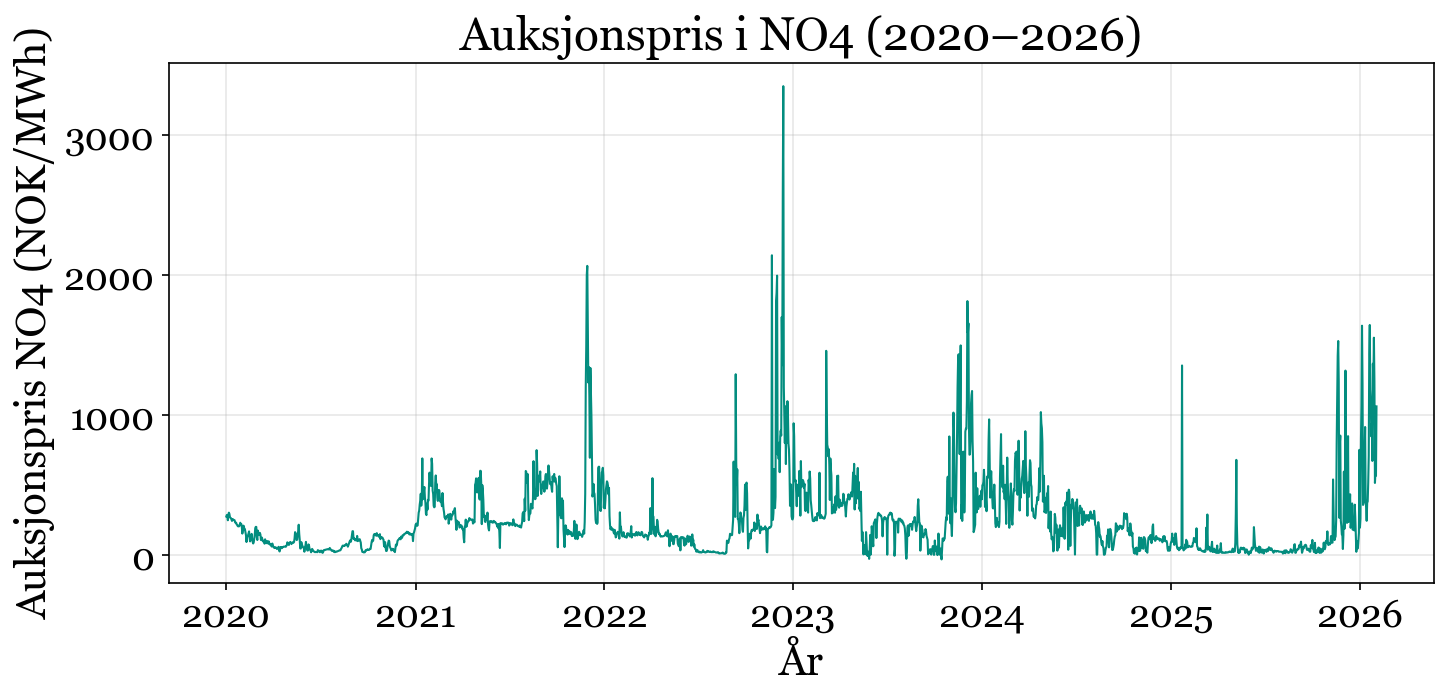

Lagret: ../figures/notebook/02/spotpris_over_tid.pdf


In [3]:
# Daglig median spotpris
daily_price = df["price_NO4"].resample("D").median()

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(daily_price.index, daily_price.values, color=C1, lw=1.0)

ax.set_xlabel("År")
ax.set_ylabel("Auksjonspris NO4 (NOK/MWh)")
ax.set_title("Auksjonspris i NO4 (2020–2026)")

plt.tight_layout()
plt.savefig(SEC4_DIR + "spotpris_over_tid.pdf", bbox_inches="tight")
plt.show()
print("Lagret:", SEC4_DIR + "spotpris_over_tid.pdf")

## Fig 4.0b — Forbruk i NO4 over tid

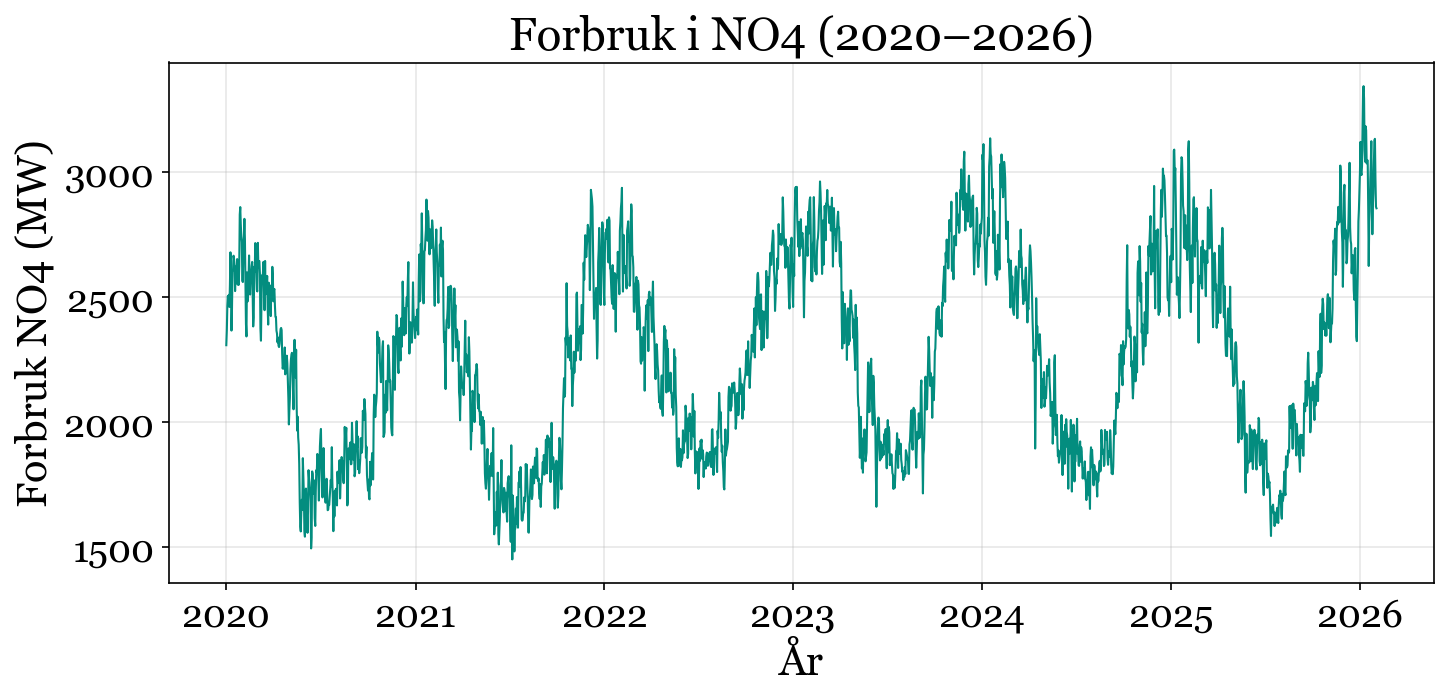

Lagret: ../figures/notebook/02/forbruk_over_tid.pdf


In [4]:
# Daglig median forbruk
daily_cons = df["cons_NO4"].resample("D").median()

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(daily_cons.index, daily_cons.values, color=C1, lw=1.0)

ax.set_xlabel("År")
ax.set_ylabel("Forbruk NO4 (MW)")
ax.set_title("Forbruk i NO4 (2020–2026)")

plt.tight_layout()
plt.savefig(SEC4_DIR + "forbruk_over_tid.pdf", bbox_inches="tight")
plt.show()
print("Lagret:", SEC4_DIR + "forbruk_over_tid.pdf")

═════════════════════════════════════════════════════════════════
PRIS og FORBRUK — ISO-timer vs. ikke-ISO-timer
═════════════════════════════════════════════════════════════════

price_NO4 (NOK/MWh)
              ISO-timer  Ikke-ISO-timer
Antall          34916.0         18478.0
Gjennomsnitt      270.7           195.3
Std.avvik         292.6           323.1
Min              -275.8          -136.6
Median            207.2            96.2
Maks             5335.1          5284.2

cons_NO4 (MW)
              ISO-timer  Ikke-ISO-timer
Antall          34916.0         18478.0
Gjennomsnitt     2276.8          2218.6
Std.avvik         410.8           384.7
Min               888.5          1135.2
Median           2281.0          2208.0
Maks             4211.0          3419.3


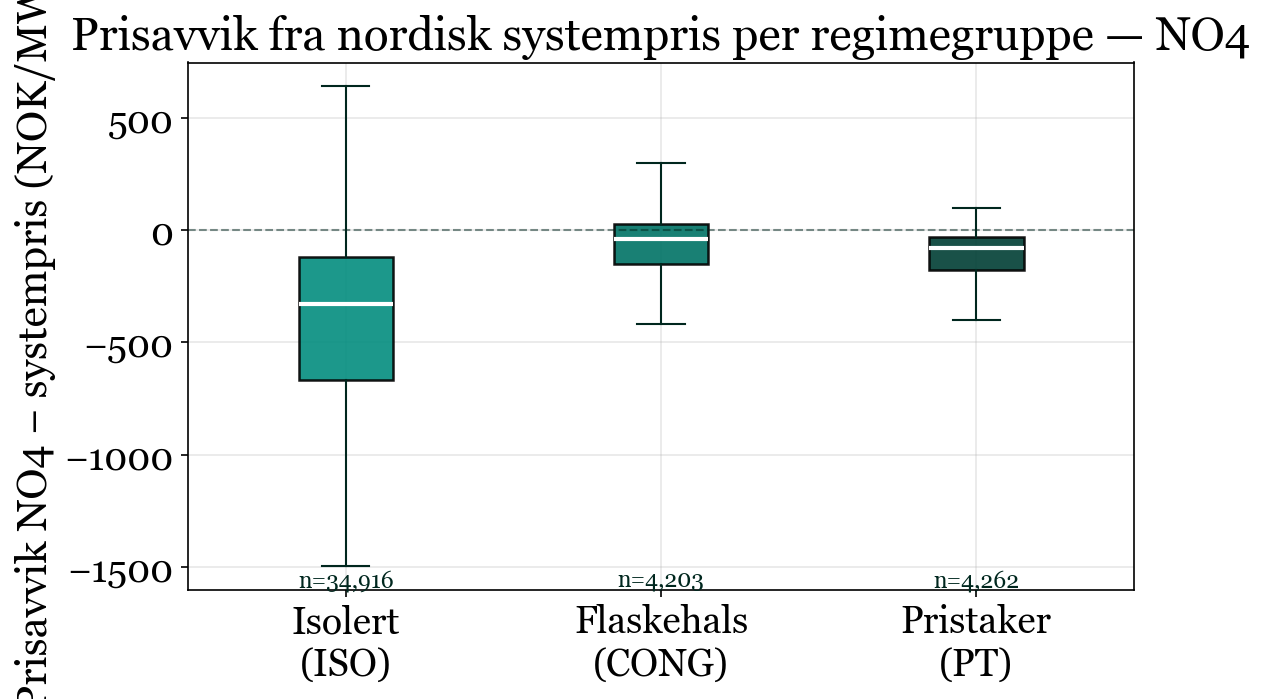

Lagret: ../figures/notebook/02/prisavvik_per_regime.pdf


In [5]:
# ISO vs. ikke-ISO — sammenligning av pris og forbruk
print("═" * 65)
print("PRIS og FORBRUK — ISO-timer vs. ikke-ISO-timer")
print("═" * 65)

iso_mask     = df["regime_group"] == "ISO"
not_iso_mask = ~iso_mask

compare = {}
for label, mask in [("ISO-timer", iso_mask), ("Ikke-ISO-timer", not_iso_mask)]:
    sub = df.loc[mask, ["price_NO4", "cons_NO4"]]
    compare[label] = sub.describe().loc[["count", "mean", "std", "min", "50%", "max"]].round(1)

for col, norsk in [("price_NO4", "price_NO4 (NOK/MWh)"), ("cons_NO4", "cons_NO4 (MW)")]:
    tbl = pd.DataFrame({lbl: compare[lbl][col] for lbl in compare})
    tbl.index = ["Antall", "Gjennomsnitt", "Std.avvik", "Min", "Median", "Maks"]
    print(f"\n{norsk}")
    print(tbl.to_string())

# Figur: prisavvik (NO4 − systempris) per regimegruppe
df["price_spread"] = df["price_NO4"] - df["system_price"]

REGIME_ORDER  = ["ISO", "CONG", "PRICE_TAKER"]
REGIME_COLORS = [C1, C2, C4]
REGIME_LABELS_FIG = {
    "ISO":         "Isolert\n(ISO)",
    "CONG":        "Flaskehals\n(CONG)",
    "PRICE_TAKER": "Pristaker\n(PT)",
}

data_by_regime = [
    df.loc[df["regime_group"] == rg, "price_spread"].dropna().values
    for rg in REGIME_ORDER
]
labels = [REGIME_LABELS_FIG[rg] for rg in REGIME_ORDER]

fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(
    data_by_regime, labels=labels,
    patch_artist=True, showfliers=False,
    medianprops=dict(color="white", linewidth=2),
    whiskerprops=dict(color=C5),
    capprops=dict(color=C5),
    boxprops=dict(linewidth=1.2),
)
for patch, color in zip(bp["boxes"], REGIME_COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.9)

ax.axhline(0, color=C5, linewidth=1, linestyle="--", alpha=0.5)

ax.set_ylabel("Prisavvik NO4 − systempris (NOK/MWh)")
ax.set_title("Prisavvik fra nordisk systempris per regimegruppe — NO4")

for i, rg in enumerate(REGIME_ORDER):
    n = (df["regime_group"] == rg).sum()
    ax.text(i + 1, ax.get_ylim()[0] + 10, f"n={n:,}",
            ha="center", fontsize=11, color=C5)

plt.tight_layout()
plt.savefig(SEC4_DIR + "prisavvik_per_regime.pdf", bbox_inches="tight")
plt.show()
print("Lagret:", SEC4_DIR + "prisavvik_per_regime.pdf")

## Fig 4.1 — Døgnprofil for forbruk per sesong

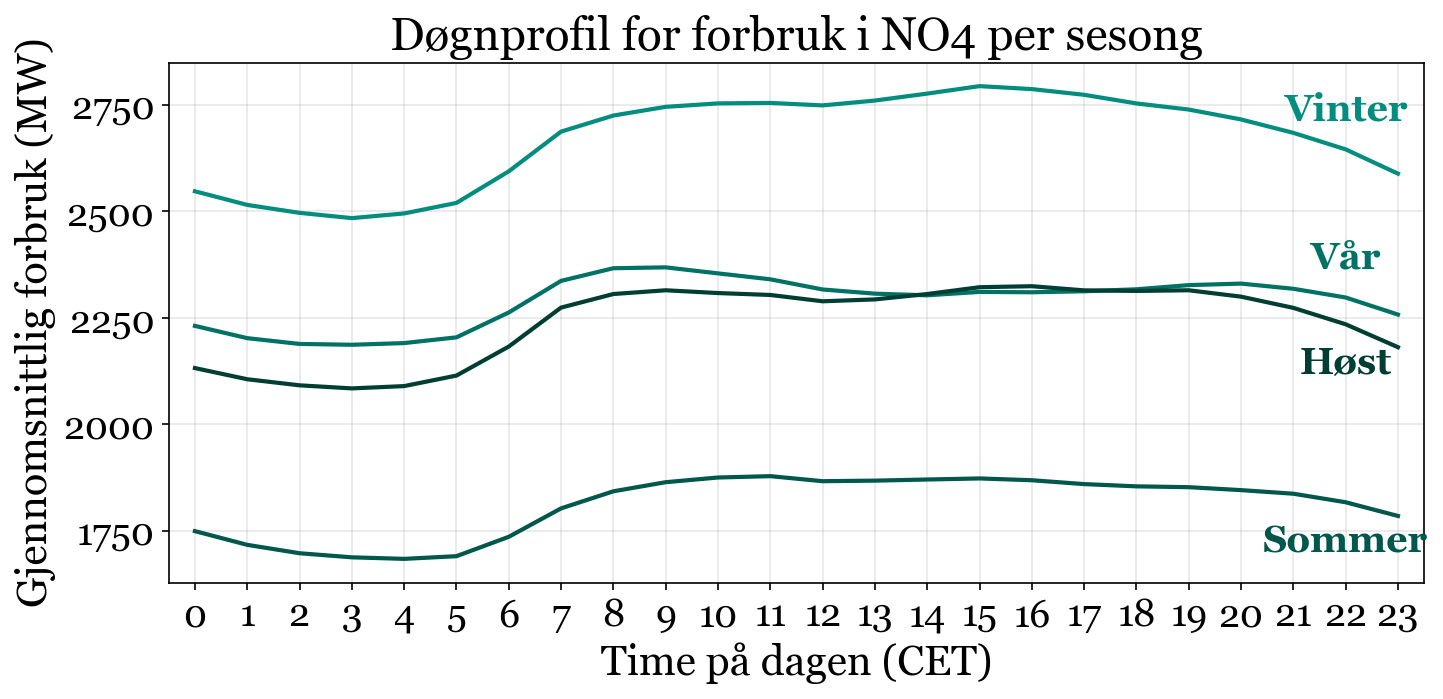

Lagret: ../figures/notebook/02/døgnprofil_forbruk.pdf


In [6]:
season_hour = df.groupby(["season", "hour"])["cons_NO4"].mean().unstack(level=0)

SEASON_COLORS = {"Winter": C1, "Spring": C2, "Summer": C3, "Autumn": C4}
SEASON_LABELS = {"Winter": "Vinter", "Spring": "Vår", "Summer": "Sommer", "Autumn": "Høst"}

label_positions = {
    "Winter": (22,  0,  10, "bottom"),
    "Autumn": (22,  0, -10, "top"),
    "Spring": (22,  0,  10, "bottom"),
    "Summer": (22,  0, -10, "top"),
}

fig, ax = plt.subplots(figsize=(10, 5))
for season in ["Winter", "Spring", "Summer", "Autumn"]:
    if season not in season_hour.columns:
        continue
    ax.plot(season_hour.index, season_hour[season],
            color=SEASON_COLORS[season], linewidth=2)

    x_pos, x_off, y_off, va = label_positions[season]
    ax.annotate(
        SEASON_LABELS[season],
        xy=(x_pos, season_hour[season].loc[x_pos]),
        xytext=(x_off, y_off), textcoords="offset points",
        color=SEASON_COLORS[season], fontweight="bold",
        ha="center", va=va,
    )

ax.set_xlabel("Time på dagen (CET)")
ax.set_ylabel("Gjennomsnittlig forbruk (MW)")
ax.set_title("Døgnprofil for forbruk i NO4 per sesong")
ax.set_xticks(range(0, 24))
ax.set_xlim(-0.5, 23.5)

plt.tight_layout()
plt.savefig(SEC4_DIR + "døgnprofil_forbruk.pdf", bbox_inches="tight")
plt.show()
print("Lagret:", SEC4_DIR + "døgnprofil_forbruk.pdf")

## Fig 4.2 — Månedlig magasinfyllingsgrad

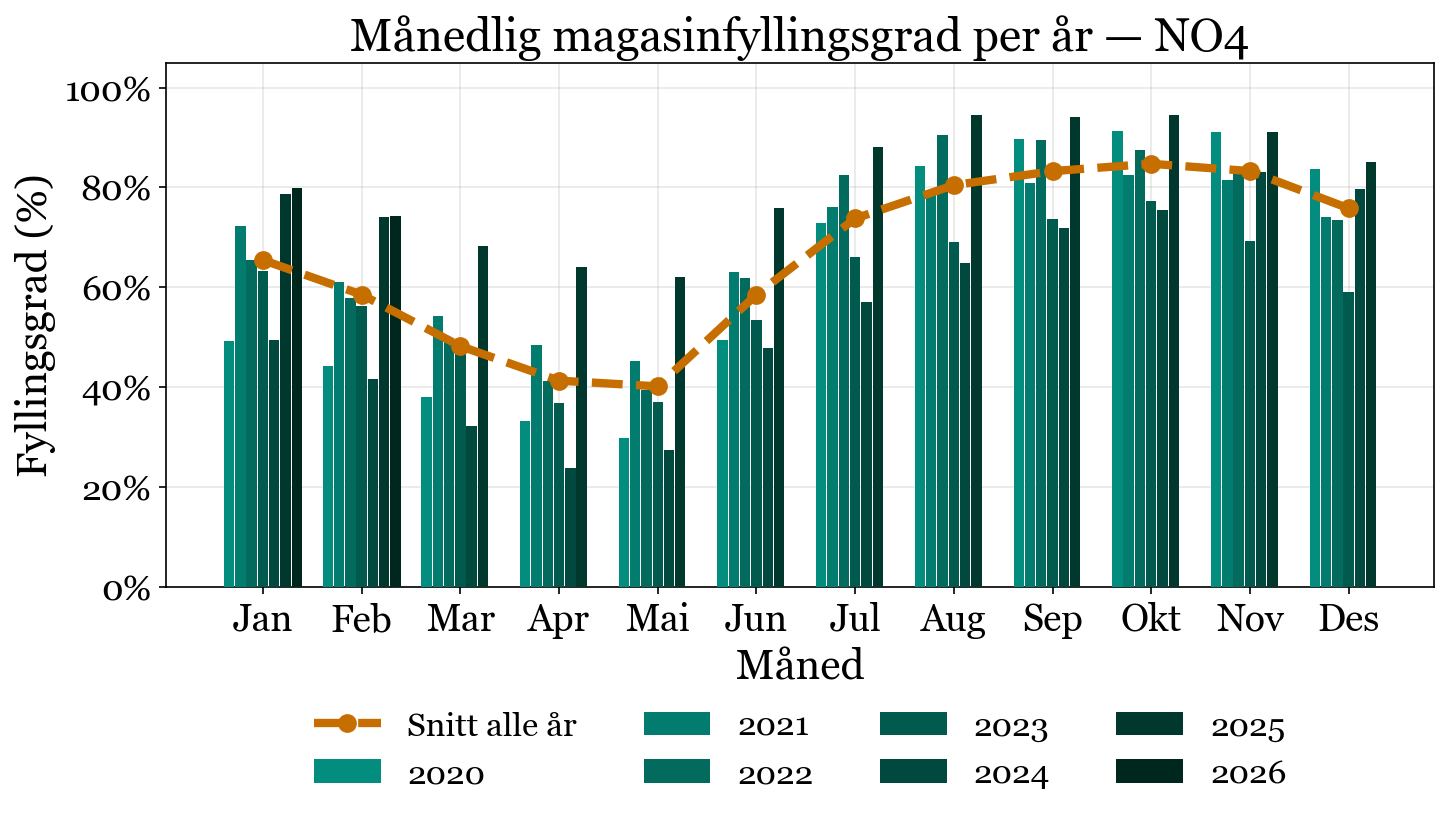

Lagret: ../figures/notebook/02/magasinfyllingsgrad_søyle.pdf


In [7]:
monthly_fill = df.groupby(["year", "month"])["fill_rate"].mean().unstack(level=0)

måneder = ["Jan", "Feb", "Mar", "Apr", "Mai", "Jun",
           "Jul", "Aug", "Sep", "Okt", "Nov", "Des"]

all_years_list = sorted(monthly_fill.columns)
n_years = len(all_years_list)

def _interp_color(c1, c2, t):
    r1, g1, b1 = [int(c1[i:i+2], 16)/255 for i in (1, 3, 5)]
    r2, g2, b2 = [int(c2[i:i+2], 16)/255 for i in (1, 3, 5)]
    return "#{:02X}{:02X}{:02X}".format(
        int((r1 + t*(r2-r1))*255), int((g1 + t*(g2-g1))*255), int((b1 + t*(b2-b1))*255))

year_colors = {
    yr: _interp_color(C1, C5, i / (n_years - 1))
    for i, yr in enumerate(all_years_list)
}

monthly_avg = monthly_fill.mean(axis=1)

x     = np.arange(12)
width = 0.8 / n_years

fig, ax = plt.subplots(figsize=(10, 6))

for i, yr in enumerate(all_years_list):
    vals   = monthly_fill[yr].values
    offset = (i - n_years / 2 + 0.5) * width
    ax.bar(x + offset, vals, width=width * 0.92,
           color=year_colors[yr], label=str(yr), zorder=3)

ax.plot(x, monthly_avg.values, color="#C76E00", linewidth=4, linestyle="--",
        marker="o", markersize=8, zorder=5, label="Snitt alle år")

ax.set_xticks(x)
ax.set_xticklabels(måneder, fontsize=18)
ax.tick_params(axis="y", labelsize=17)
ax.set_xlabel("Måned", fontsize=20)
ax.set_ylabel("Fyllingsgrad (%)", fontsize=20)
ax.set_title("Månedlig magasinfyllingsgrad per år — NO4", fontsize=22)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.set_ylim(0, 1.05)

handles, labels_leg = ax.get_legend_handles_labels()
ax.legend(handles, labels_leg, ncol=4, frameon=False,
          bbox_to_anchor=(0.5, -0.18), loc="upper center", fontsize=16)

plt.tight_layout()
plt.savefig(SEC4_DIR + "magasinfyllingsgrad_søyle.pdf", bbox_inches="tight")
plt.show()
print("Lagret:", SEC4_DIR + "magasinfyllingsgrad_søyle.pdf")

## Fig 4.3 — Korrelasjonsmatrise

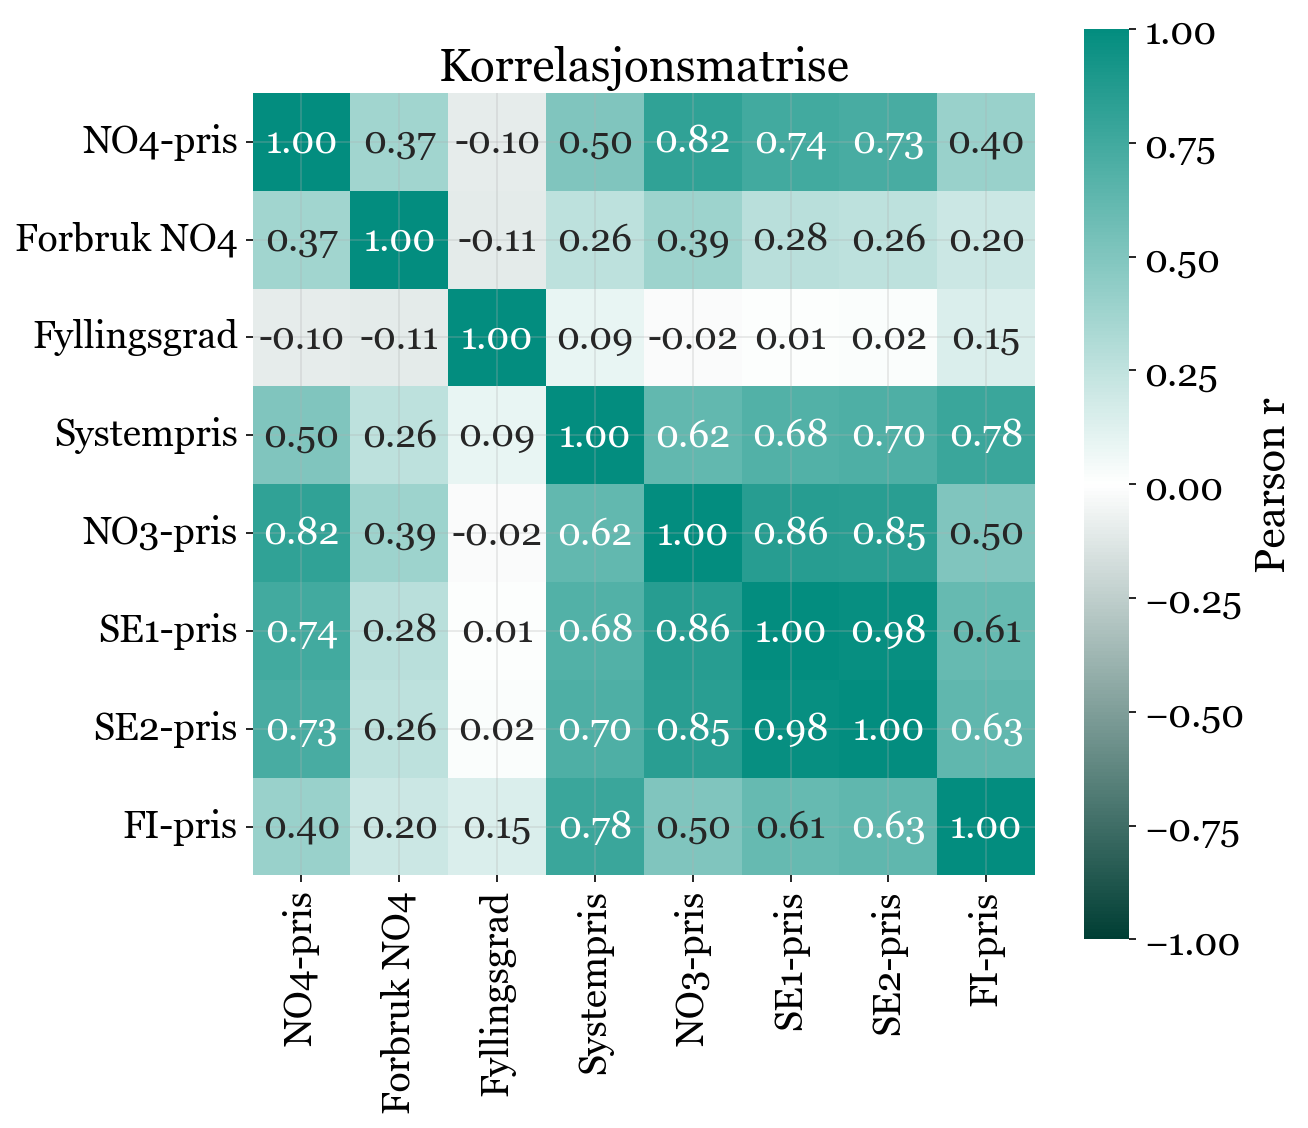

Lagret: ../figures/notebook/02/korrelasjonsmatrise.pdf


In [8]:
teal_div = LinearSegmentedColormap.from_list("teal_div", [C4, "#FFFFFF", C1])

corr_vars = ["price_NO4", "cons_NO4", "fill_rate",
             "system_price", "price_NO3", "price_SE1", "price_SE2", "price_FI"]
corr_labels = ["NO4-pris", "Forbruk NO4", "Fyllingsgrad",
               "Systempris", "NO3-pris", "SE1-pris", "SE2-pris", "FI-pris"]

corr_matrix = df[corr_vars].corr()
corr_matrix.index = corr_labels
corr_matrix.columns = corr_labels

fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", cmap=teal_div,
    center=0, vmin=-1, vmax=1, square=True,
    linewidths=0, linecolor="none",
    cbar_kws={"label": "Pearson r"}, ax=ax,
)
ax.set_title("Korrelasjonsmatrise")

plt.tight_layout()
plt.savefig(SEC4_DIR + "korrelasjonsmatrise.pdf", bbox_inches="tight")
plt.show()
print("Lagret:", SEC4_DIR + "korrelasjonsmatrise.pdf")

## Fig 4.3b — Korrelasjonsmatrise (ISO-timer)

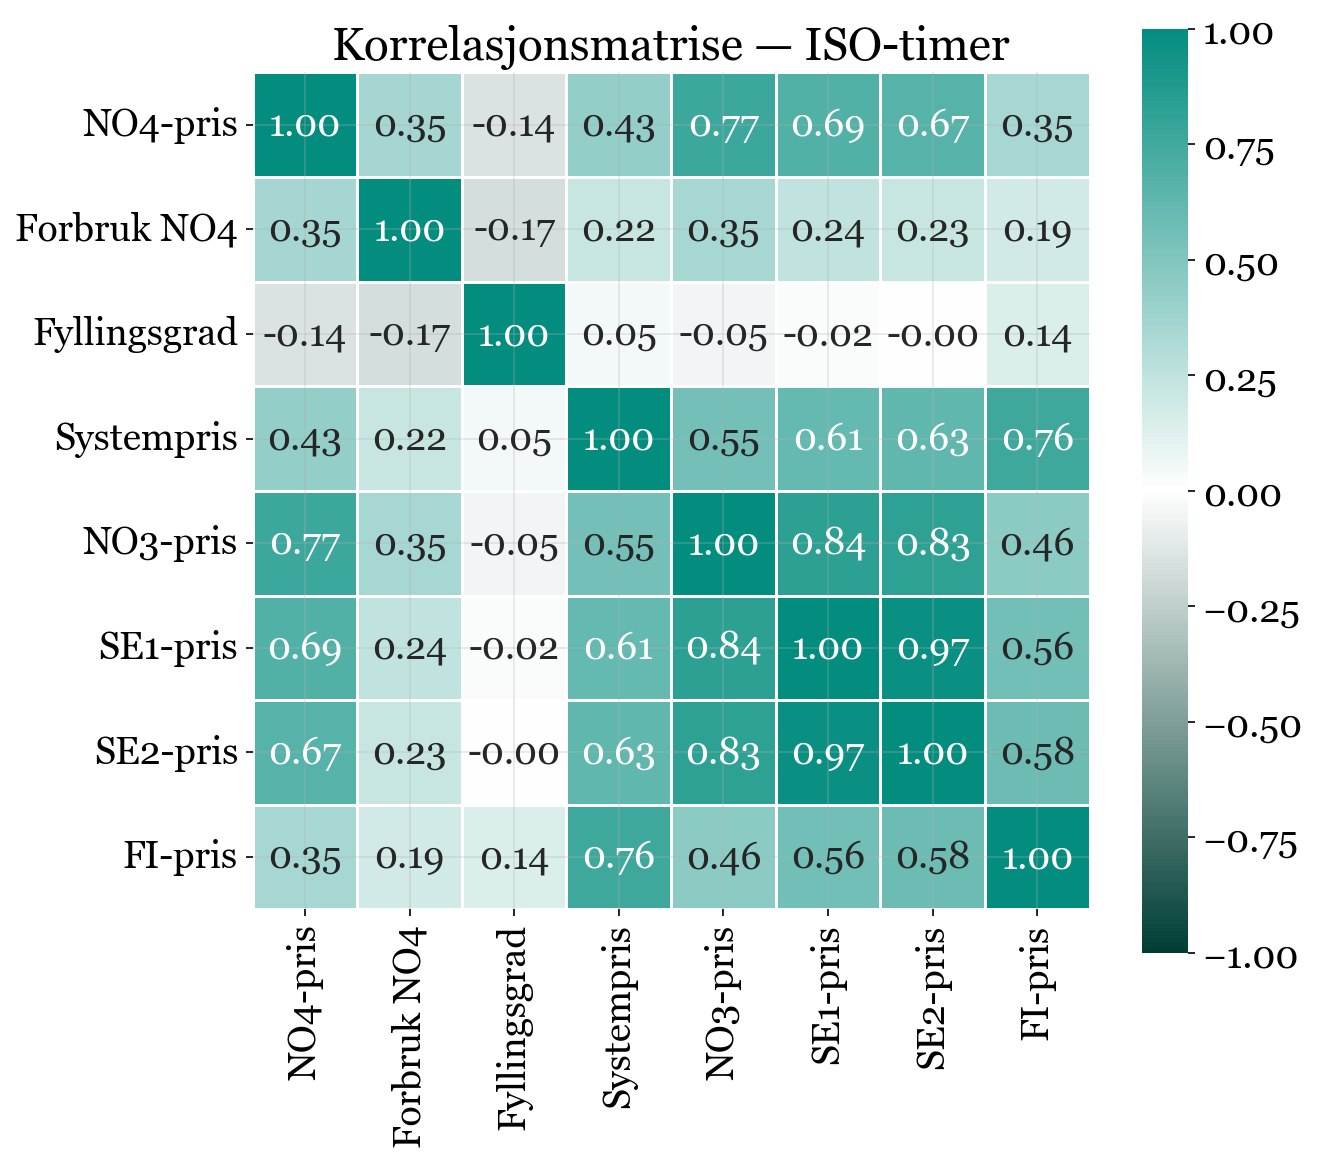

Lagret: ../figures/notebook/02/korrelasjonsmatrise_iso.pdf


In [9]:
df_iso_desc = df[df["regime_group"] == "ISO"].copy()

corr_matrix_iso = df_iso_desc[corr_vars].corr()
corr_matrix_iso.index = corr_labels
corr_matrix_iso.columns = corr_labels

fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(
    corr_matrix_iso, annot=True, fmt=".2f", cmap=teal_div,
    vmin=-1, vmax=1, linewidths=0.5, square=True, ax=ax
)
ax.set_title("Korrelasjonsmatrise — ISO-timer")

plt.savefig(SEC4_DIR + "korrelasjonsmatrise_iso.pdf", bbox_inches="tight")
plt.show()
print("Lagret:", SEC4_DIR + "korrelasjonsmatrise_iso.pdf")

## Fig 4.4 — Forbruk vs. pris (ISO vs. ikke-ISO)

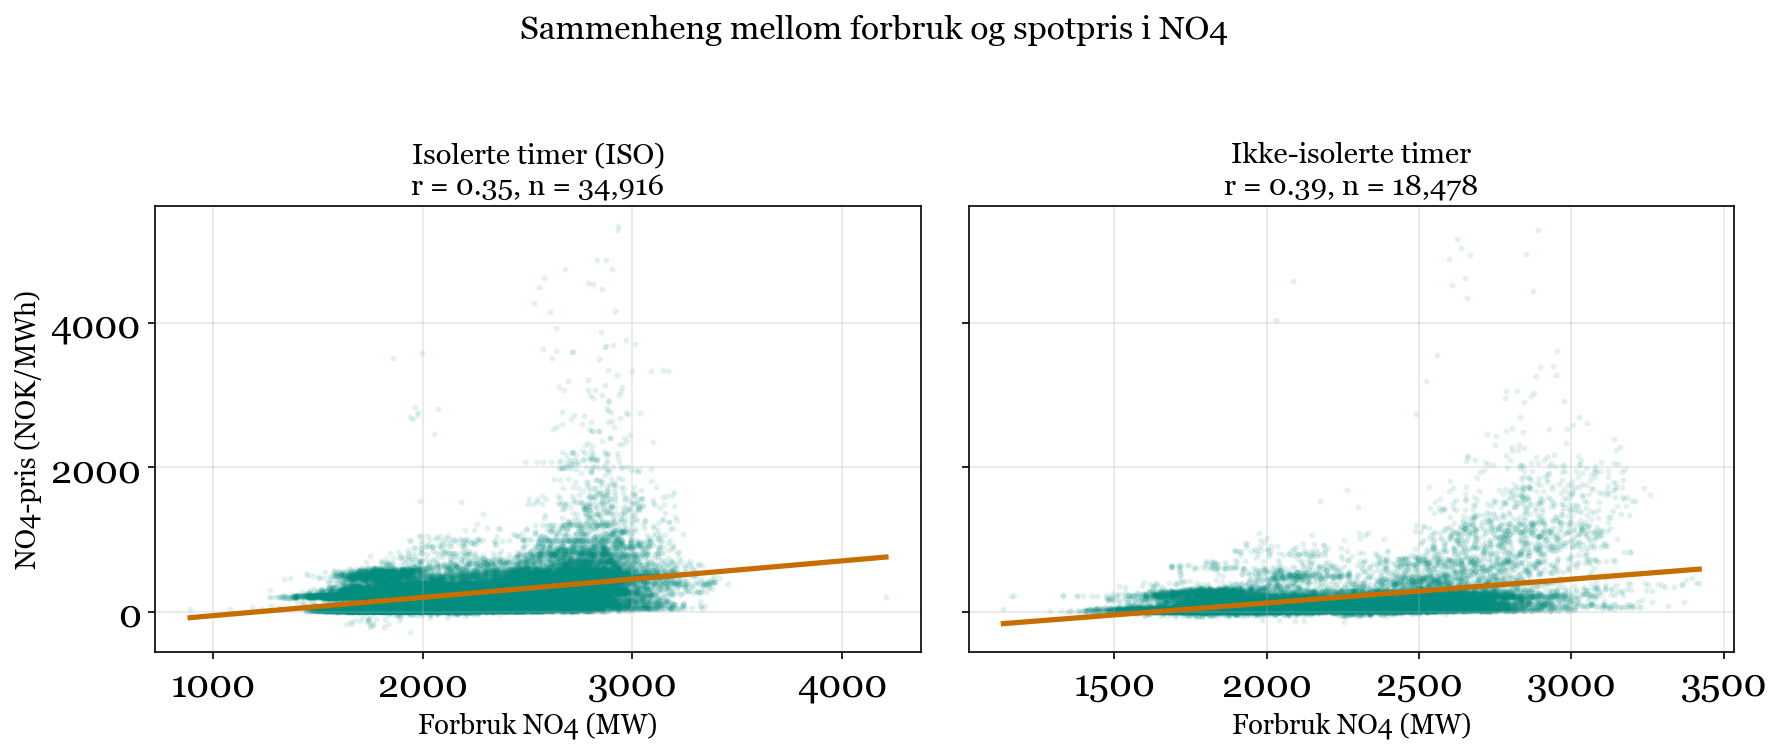

Lagret: ../figures/notebook/02/forbruk_vs_pris_regime.pdf


In [10]:
iso_mask = df["regime_group"] == "ISO"

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, mask, title in [
    (axes[0], iso_mask, "Isolerte timer (ISO)"),
    (axes[1], ~iso_mask, "Ikke-isolerte timer"),
]:
    sub = df.loc[mask]
    ax.scatter(sub["cons_NO4"], sub["price_NO4"],
               alpha=0.08, s=4, color=C1, rasterized=True)

    z = np.polyfit(sub["cons_NO4"], sub["price_NO4"], 1)
    x_line = np.linspace(sub["cons_NO4"].min(), sub["cons_NO4"].max(), 100)
    ax.plot(x_line, np.polyval(z, x_line), color="#C76E00", linewidth=2.5)

    r, _ = pearsonr(sub["cons_NO4"], sub["price_NO4"])
    n = len(sub)
    ax.set_title(f"{title}\nr = {r:.2f}, n = {n:,}", fontsize=14)
    ax.set_xlabel("Forbruk NO4 (MW)", fontsize=13)

axes[0].set_ylabel("NO4-pris (NOK/MWh)", fontsize=13)

fig.suptitle("Sammenheng mellom forbruk og spotpris i NO4", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(SEC4_DIR + "forbruk_vs_pris_regime.pdf", bbox_inches="tight")
plt.show()
print("Lagret:", SEC4_DIR + "forbruk_vs_pris_regime.pdf")

## Fig 4.5 — Fyllingsgrad vs. pris

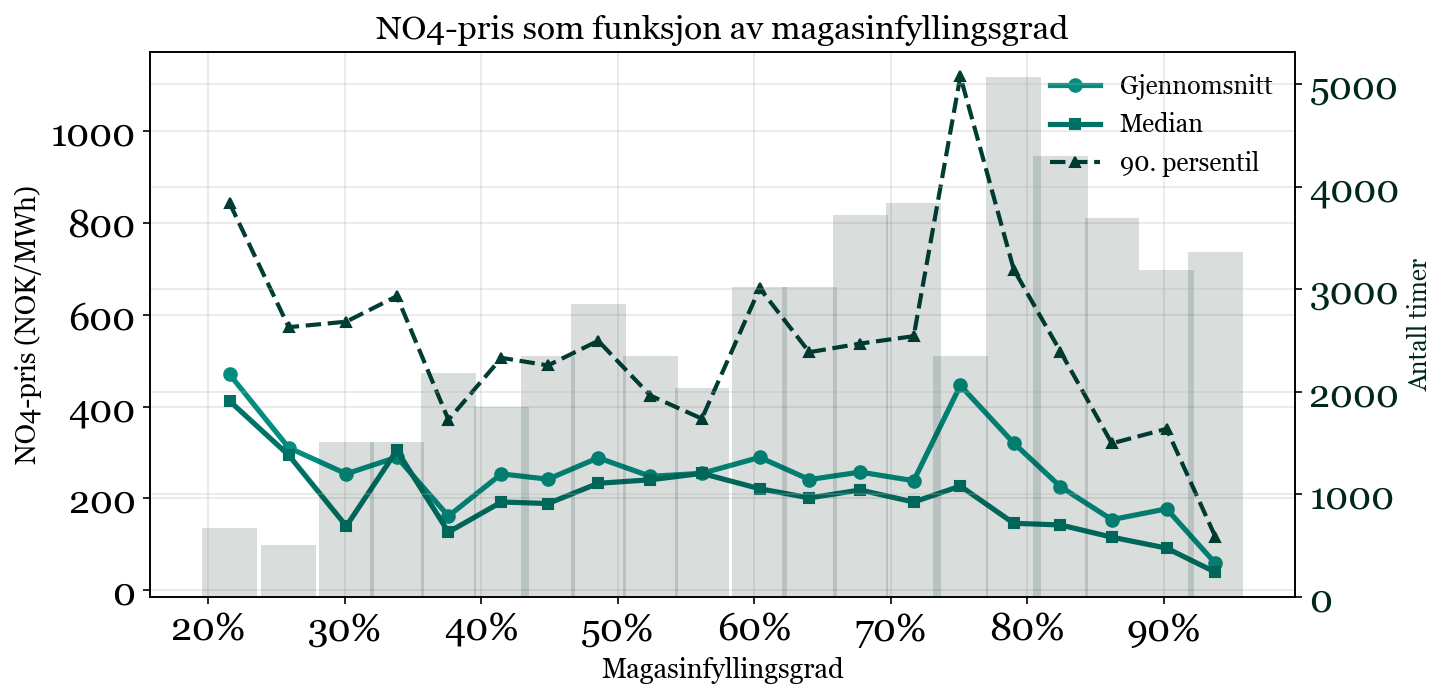

Lagret: ../figures/notebook/02/fyllingsgrad_vs_pris.pdf


In [11]:
n_bins = 20
df["fill_bin"] = pd.cut(df["fill_rate"], bins=n_bins)

binned = df.groupby("fill_bin", observed=True).agg(
    mean_price=("price_NO4", "mean"),
    median_price=("price_NO4", "median"),
    q90_price=("price_NO4", lambda x: x.quantile(0.90)),
    count=("price_NO4", "size"),
    fill_mid=("fill_rate", "mean"),
).sort_values("fill_mid")

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(binned["fill_mid"], binned["mean_price"],
         color=C1, linewidth=2.5, marker="o", markersize=6, label="Gjennomsnitt")
ax1.plot(binned["fill_mid"], binned["median_price"],
         color=C2, linewidth=2.5, marker="s", markersize=5, label="Median")
ax1.plot(binned["fill_mid"], binned["q90_price"],
         color=C4, linewidth=2, linestyle="--", marker="^", markersize=5, label="90. persentil")

ax1.set_xlabel("Magasinfyllingsgrad", fontsize=13)
ax1.set_ylabel("NO4-pris (NOK/MWh)", fontsize=13)
ax1.set_title("NO4-pris som funksjon av magasinfyllingsgrad", fontsize=16)
ax1.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax1.legend(fontsize=12, frameon=False)

ax2 = ax1.twinx()
ax2.bar(binned["fill_mid"], binned["count"],
        width=0.04, alpha=0.15, color=C5, zorder=0)
ax2.set_ylabel("Antall timer", fontsize=12, color=C5)
ax2.tick_params(axis="y", labelcolor=C5)

plt.tight_layout()
plt.savefig(SEC4_DIR + "fyllingsgrad_vs_pris.pdf", bbox_inches="tight")
plt.show()
print("Lagret:", SEC4_DIR + "fyllingsgrad_vs_pris.pdf")

df = df.drop(columns=["fill_bin", "year", "price_spread"], errors="ignore")

## Fig 4.6 — Nedbør og spotpris i NO4

Viser sammenhengen mellom daglig nedbør (Narvik Sentrum, met.no) og spotpris i NO4, fordelt på prisregime.

Khazal mfl. (2023) finner en positiv nedbørseffekt i ukentlig norsk paneldata — her undersøkes om mønsteret gjenfinnes i NO4 på timesnivå.

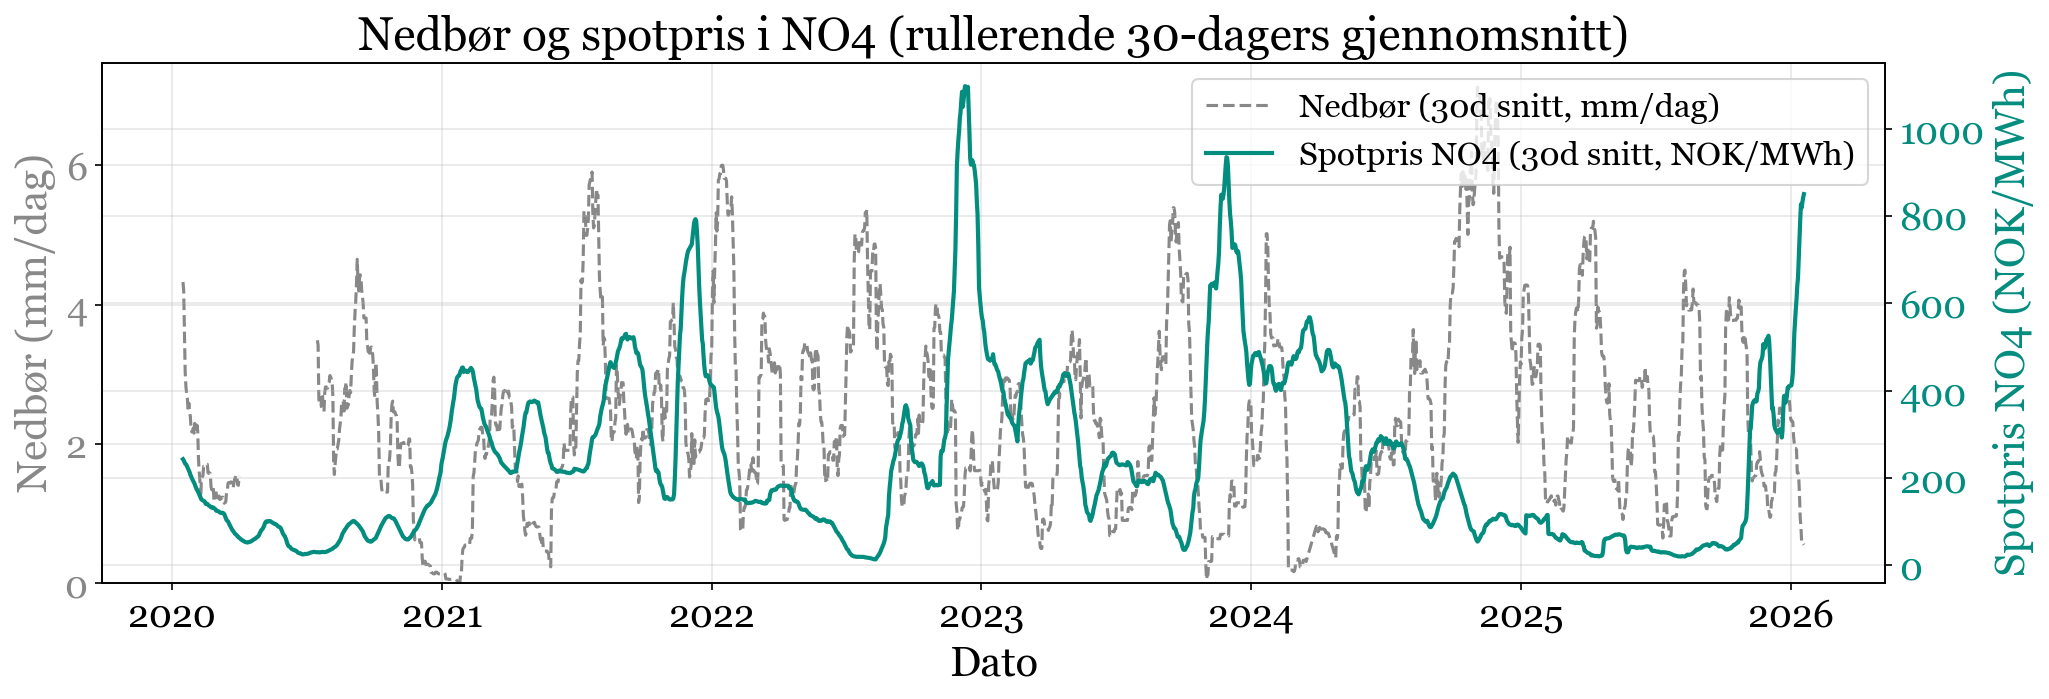

In [12]:
if 'precip_NO4' not in df.columns:
    print('ADVARSEL: precip_NO4 mangler — kjør NB01 på nytt.')
else:
    daily = df.copy()
    daily['date'] = daily.index.normalize()
    daily_agg = daily.groupby('date').agg(
        price_NO4=('price_NO4', 'median'),
        precip_NO4=('precip_NO4', 'first'),
    )
    roll_price  = daily_agg['price_NO4'].rolling(30, center=True).mean()
    roll_precip = daily_agg['precip_NO4'].rolling(30, center=True).mean()

    GREY = '#888888'

    fig, ax1 = plt.subplots(figsize=(14, 5))

    ax1.plot(daily_agg.index, roll_precip,
             color=GREY, lw=1.5, ls='--', label='Nedbør (30d snitt, mm/dag)')
    ax1.set_ylabel('Nedbør (mm/dag)', color=GREY)
    ax1.tick_params(axis='y', labelcolor=GREY)
    ax1.set_ylim(bottom=0)

    ax2 = ax1.twinx()
    ax2.plot(daily_agg.index, roll_price,
             color=C1, lw=2, label='Spotpris NO4 (30d snitt, NOK/MWh)')
    ax2.set_ylabel('Spotpris NO4 (NOK/MWh)', color=C1)
    ax2.tick_params(axis='y', labelcolor=C1)

    ax1.set_xlabel('Dato')
    ax1.set_title('Nedbør og spotpris i NO4 (rullerende 30-dagers gjennomsnitt)')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

    plt.tight_layout()
    fig.savefig(f'{SEC4_DIR}fig_4_6_nedbor_pris.pdf', bbox_inches='tight')
    fig.savefig(f'{SEC4_DIR}fig_4_6_nedbor_pris.png', bbox_inches='tight')
    plt.show()

## Fig 4.7 — Forbruk og spotpris i NO4

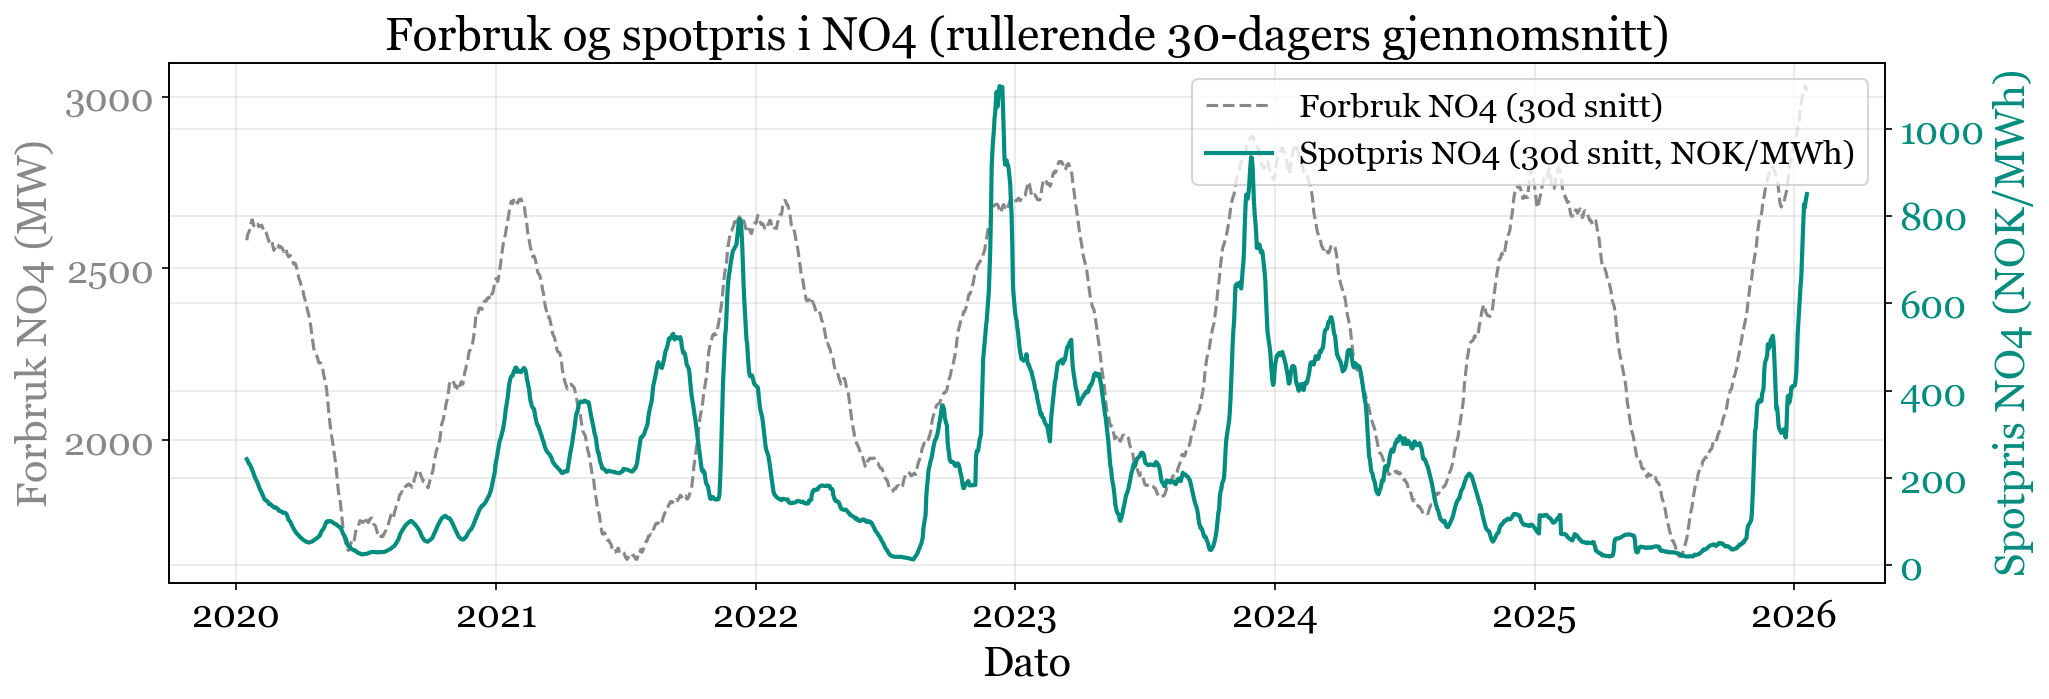

In [13]:
if 'cons_NO4' not in df.columns:
    print('ADVARSEL: cons_NO4 mangler — kjør NB01 på nytt.')
else:
    daily = df.copy()
    daily['date'] = daily.index.normalize()
    daily_agg = daily.groupby('date').agg(
        price_NO4=('price_NO4', 'median'),
        cons_NO4=('cons_NO4', 'median'),
    )
    roll_price = daily_agg['price_NO4'].rolling(30, center=True).mean()
    roll_var   = daily_agg['cons_NO4'].rolling(30, center=True).mean()

    GREY = '#888888'
    fig, ax1 = plt.subplots(figsize=(14, 5))

    ax1.plot(daily_agg.index, roll_var,
             color=GREY, lw=1.5, ls='--', label='Forbruk NO4 (30d snitt)')
    ax1.set_ylabel('Forbruk NO4 (MW)', color=GREY)
    ax1.tick_params(axis='y', labelcolor=GREY)

    ax2 = ax1.twinx()
    ax2.plot(daily_agg.index, roll_price,
             color=C1, lw=2, label='Spotpris NO4 (30d snitt, NOK/MWh)')
    ax2.set_ylabel('Spotpris NO4 (NOK/MWh)', color=C1)
    ax2.tick_params(axis='y', labelcolor=C1)

    ax1.set_xlabel('Dato')
    ax1.set_title('Forbruk og spotpris i NO4 (rullerende 30-dagers gjennomsnitt)')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

    plt.tight_layout()
    fig.savefig(f'{SEC4_DIR}fig_4_7_forbruk_pris.pdf', bbox_inches='tight')
    fig.savefig(f'{SEC4_DIR}fig_4_7_forbruk_pris.png', bbox_inches='tight')
    plt.show()

## Fig 4.8 — Temperatur og spotpris i NO4

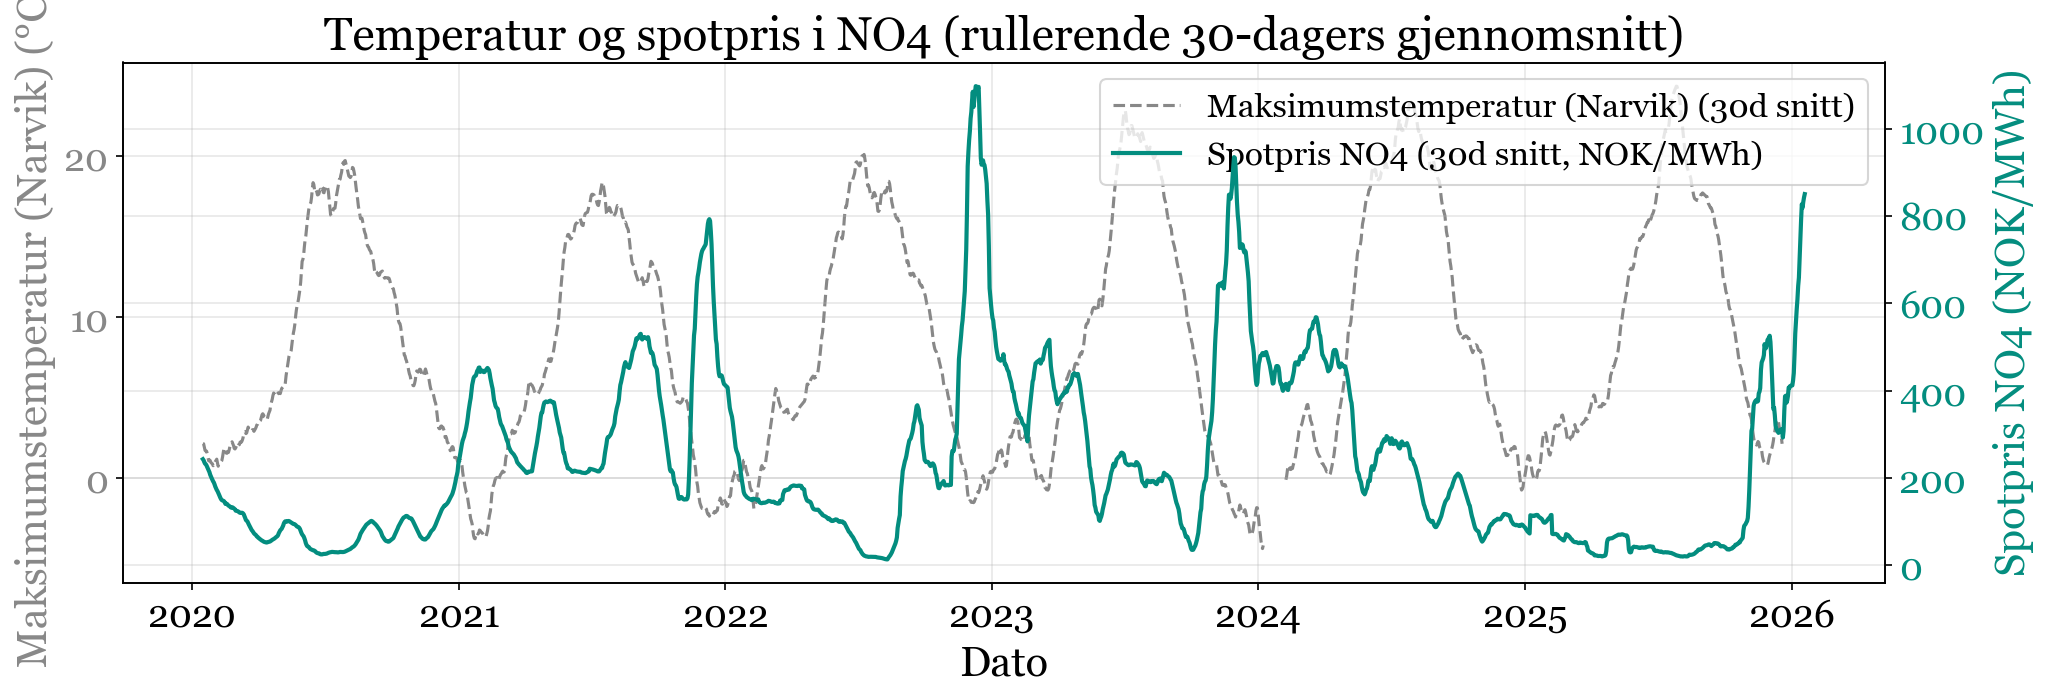

In [14]:
if 'temp_NO4' not in df.columns:
    print('ADVARSEL: temp_NO4 mangler — kjør NB01 på nytt.')
else:
    daily = df.copy()
    daily['date'] = daily.index.normalize()
    daily_agg = daily.groupby('date').agg(
        price_NO4=('price_NO4', 'median'),
        temp_NO4=('temp_NO4', 'first'),
    )
    roll_price = daily_agg['price_NO4'].rolling(30, center=True).mean()
    roll_var   = daily_agg['temp_NO4'].rolling(30, center=True).mean()

    GREY = '#888888'
    fig, ax1 = plt.subplots(figsize=(14, 5))

    ax1.plot(daily_agg.index, roll_var,
             color=GREY, lw=1.5, ls='--', label='Maksimumstemperatur (Narvik) (30d snitt)')
    ax1.set_ylabel('Maksimumstemperatur (Narvik) (°C)', color=GREY)
    ax1.tick_params(axis='y', labelcolor=GREY)

    ax2 = ax1.twinx()
    ax2.plot(daily_agg.index, roll_price,
             color=C1, lw=2, label='Spotpris NO4 (30d snitt, NOK/MWh)')
    ax2.set_ylabel('Spotpris NO4 (NOK/MWh)', color=C1)
    ax2.tick_params(axis='y', labelcolor=C1)

    ax1.set_xlabel('Dato')
    ax1.set_title('Temperatur og spotpris i NO4 (rullerende 30-dagers gjennomsnitt)')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

    plt.tight_layout()
    fig.savefig(f'{SEC4_DIR}fig_4_8_temperatur_pris.pdf', bbox_inches='tight')
    fig.savefig(f'{SEC4_DIR}fig_4_8_temperatur_pris.png', bbox_inches='tight')
    plt.show()